Cylinder Flow (Steady) DEMO code

This notebook demonstrates solving steady-state Cavity Flow with the same setup as https://www.comsol.com/blogs/how-to-solve-a-classic-cfd-benchmark-the-lid-driven-cavity-problem.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain: a rectangle with a circular obstacle (cylinder). This defines the area for simulation.

In [2]:
rectangle = df.geometry.rectangle([0, 1], [0, 1])

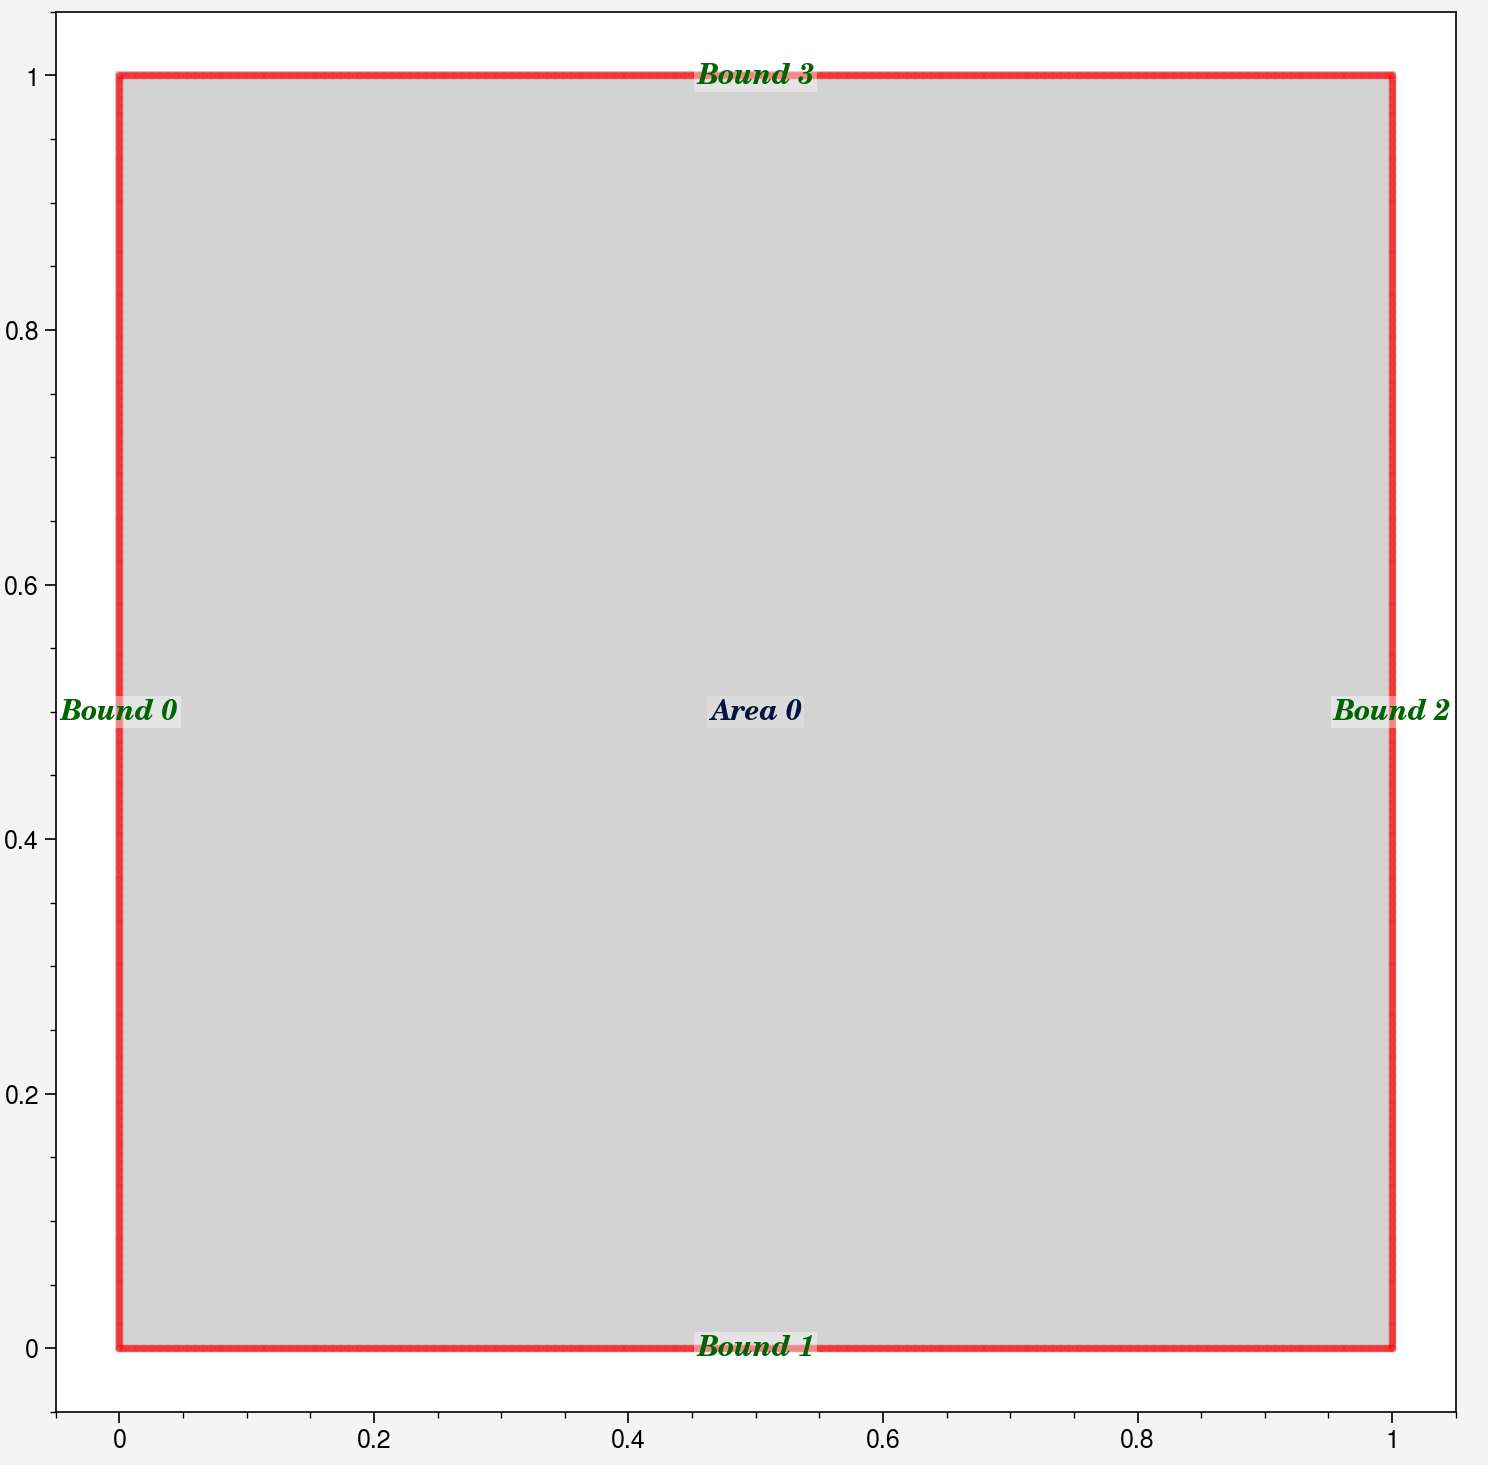

In [3]:
domain = df.domain(rectangle)
domain.show_setup()

## 2. Define Physics
Define the Navier-Stokes equations for fluid flow and apply boundary conditions (e.g., no-slip walls, inlet velocity).

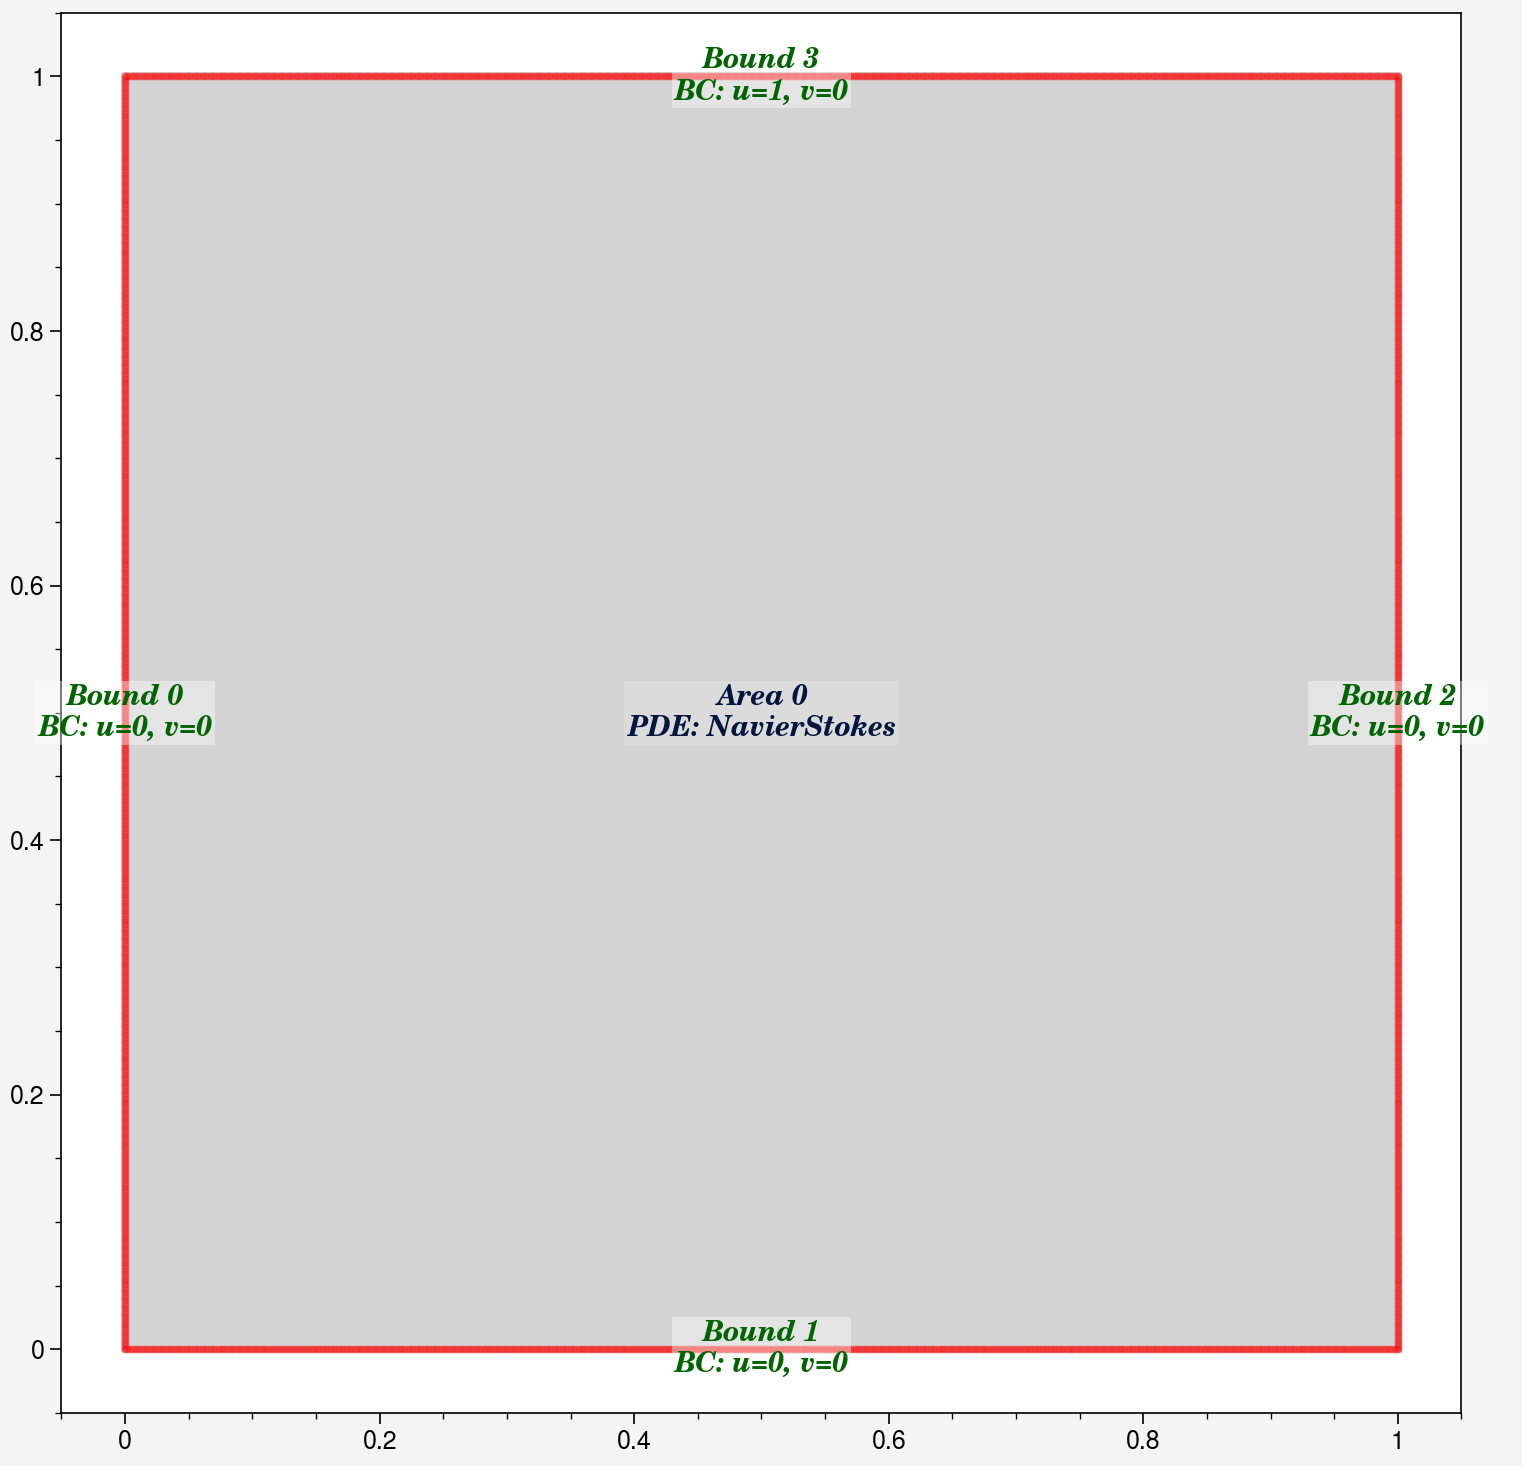

In [4]:
domain.bound_list[0].define_bc({'u': 0,'v': 0})
domain.bound_list[1].define_bc({'u': 0,'v': 0})
domain.bound_list[2].define_bc({'u': 0,'v': 0})
domain.bound_list[3].define_bc({'u': 1, 'v': 0})
domain.area_list[0].define_pde(df.NavierStokes(U=0.0001, L=1, mu=0.001, rho=1000))
domain.show_setup()


Sample initial points for training.

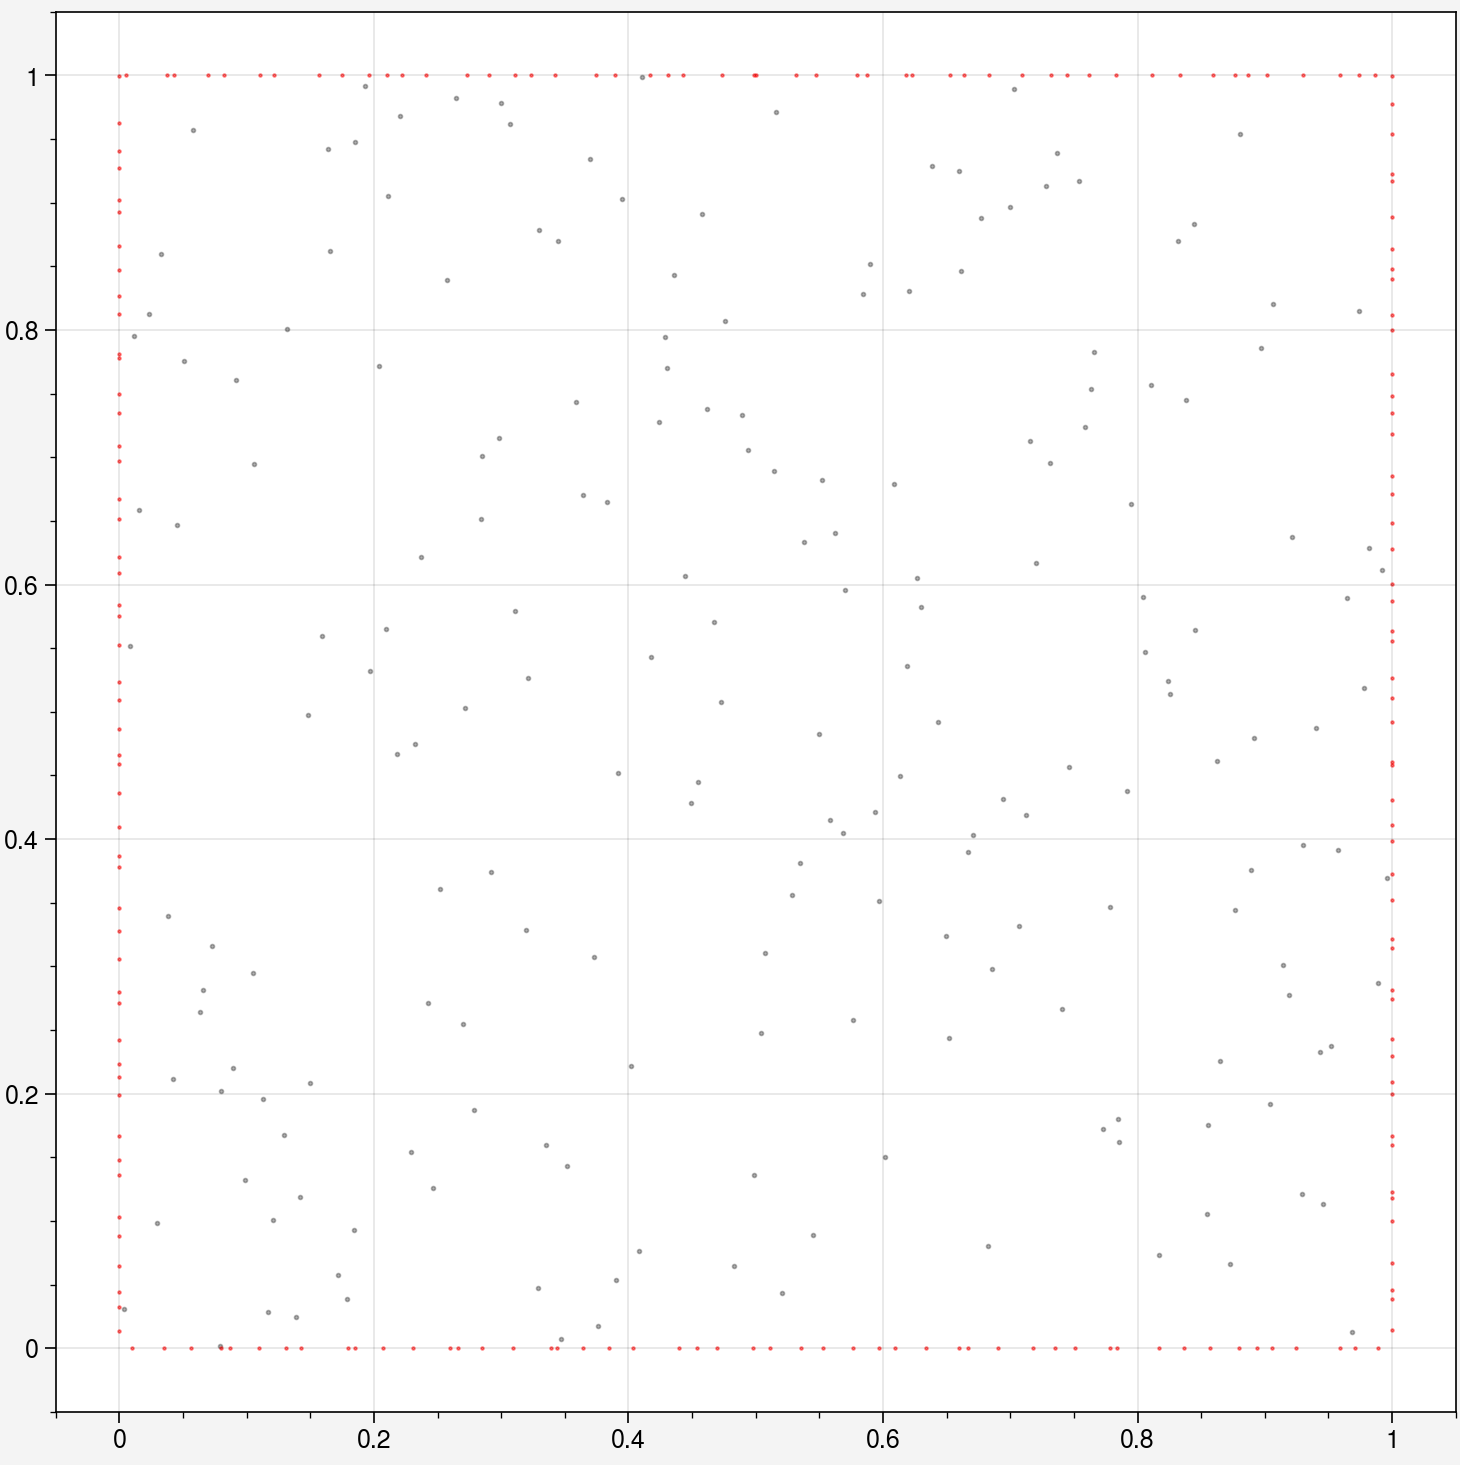

In [5]:
domain.sampling_lhs(bound_sampling_res=[50, 50, 50, 50], area_sampling_res=[200])
domain.show_coordinates(display_physics=False)

## 3. Train the PINN model

Define how collocation points are sampled during training.

In [6]:
def do_in_adam(epoch, model):
    if epoch > 0:
        domain.sampling_R3(area_sampling_res=[200])
        if epoch % 400 == 0:
            domain.show_coordinates(display_physics=False, display_resampling=True)
            print(domain)
        
def do_in_lbfgs(epoch, model):
    if epoch > 0:
        domain.sampling_R3(area_sampling_res=[200])
        if epoch % 50 == 0:
            domain.show_coordinates(display_physics=False, display_resampling=True)        
            print(domain)

Train the model using Adam for initial training (faster convergence).

In [ ]:
model0 = df.PINN(width=16, length=4, input_vars=['x','y'], output_vars=['u','v','p'])

# Train the model
model1, model1best = model0.train_adam(
    learning_rate=0.004,
    epochs=2000,
    calc_loss=df.calc_loss_weighted(domain, pde_weights=1),
    threshold_loss=0.001,
    do_between_epochs=do_in_adam)

Epoch: 1, total_loss: 1.53995, bc_loss: 1.53558, pde_loss: 0.00437


Refine the model using LBFGS for higher precision.

Epoch: 2001, total_loss: 0.07822, bc_loss: 0.06851, pde_loss: 0.00971
Epoch: 2051, total_loss: 0.03683, bc_loss: 0.02934, pde_loss: 0.00749


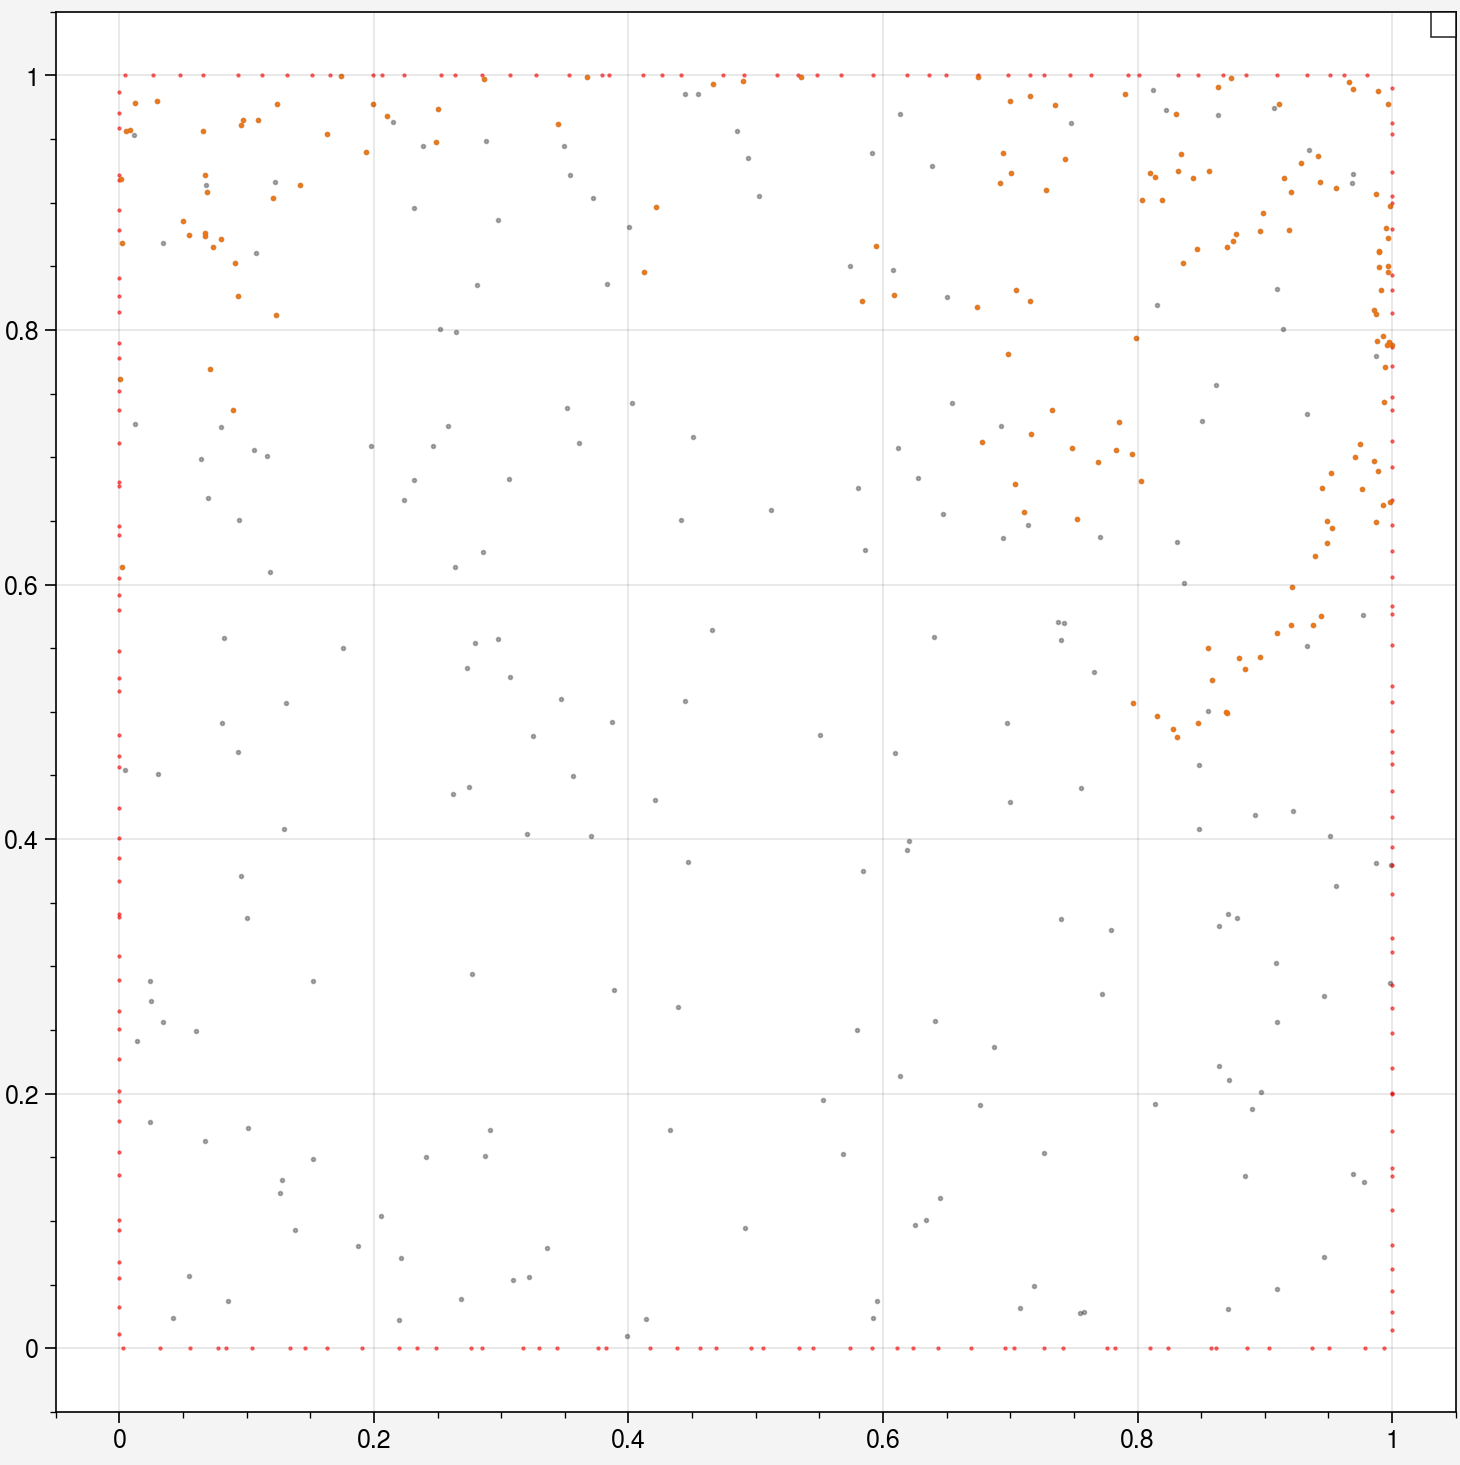

number of bound : ['0: 50', '1: 50', '2: 50', '3: 50']
number of area : ['0: 353']
Epoch: 2101, total_loss: 0.03013, bc_loss: 0.02408, pde_loss: 0.00604


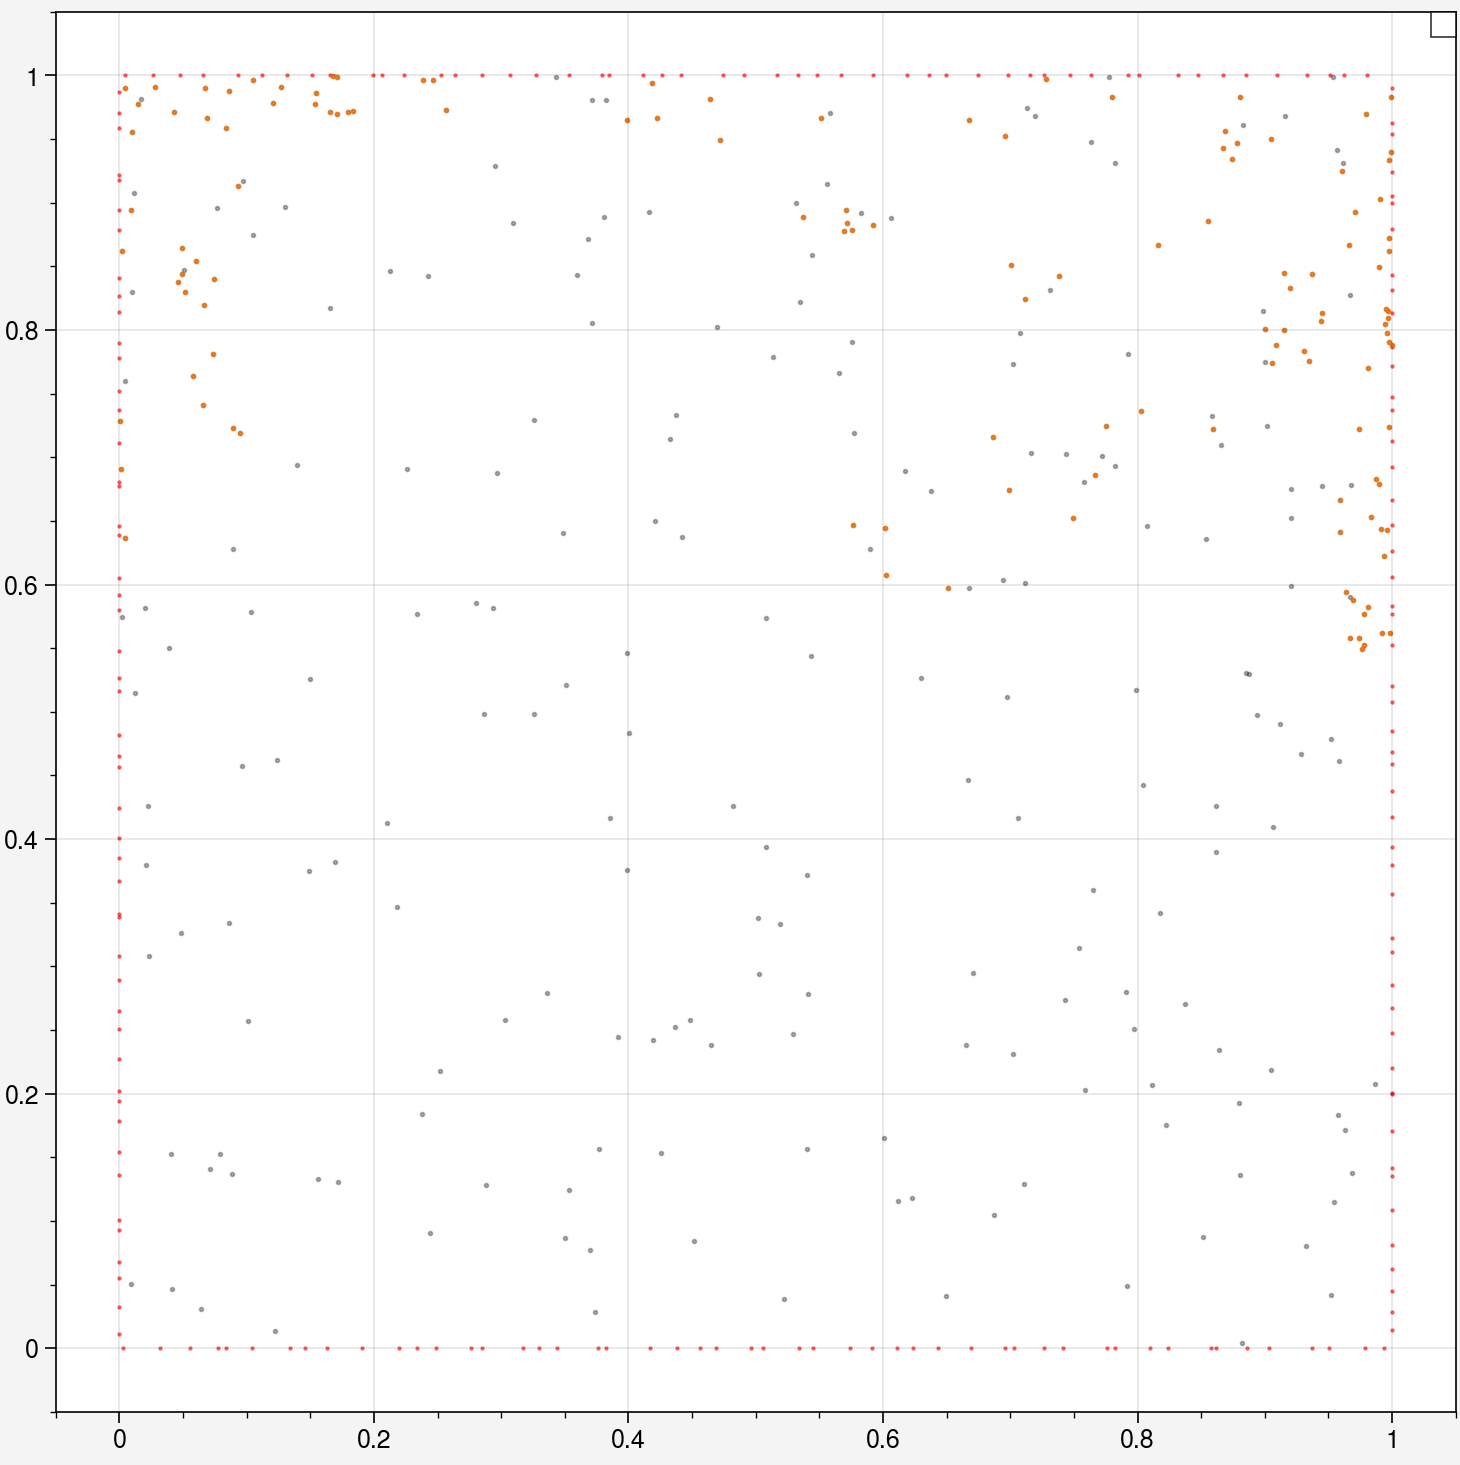

number of bound : ['0: 50', '1: 50', '2: 50', '3: 50']
number of area : ['0: 329']
Epoch: 2150, total_loss: 0.01848, bc_loss: 0.01242, pde_loss: 0.00607


In [ ]:
# Train the model
model2 = model1.train_lbfgs(
    calc_loss=df.calc_loss_weighted(domain, pde_weights=1),
    epochs=150,
    threshold_loss=0.0001,
    do_between_epochs=do_in_lbfgs)

Epoch: 2151, total_loss: 0.01860, bc_loss: 0.01259, pde_loss: 0.00601
Epoch: 2201, total_loss: 0.01776, bc_loss: 0.01351, pde_loss: 0.00425


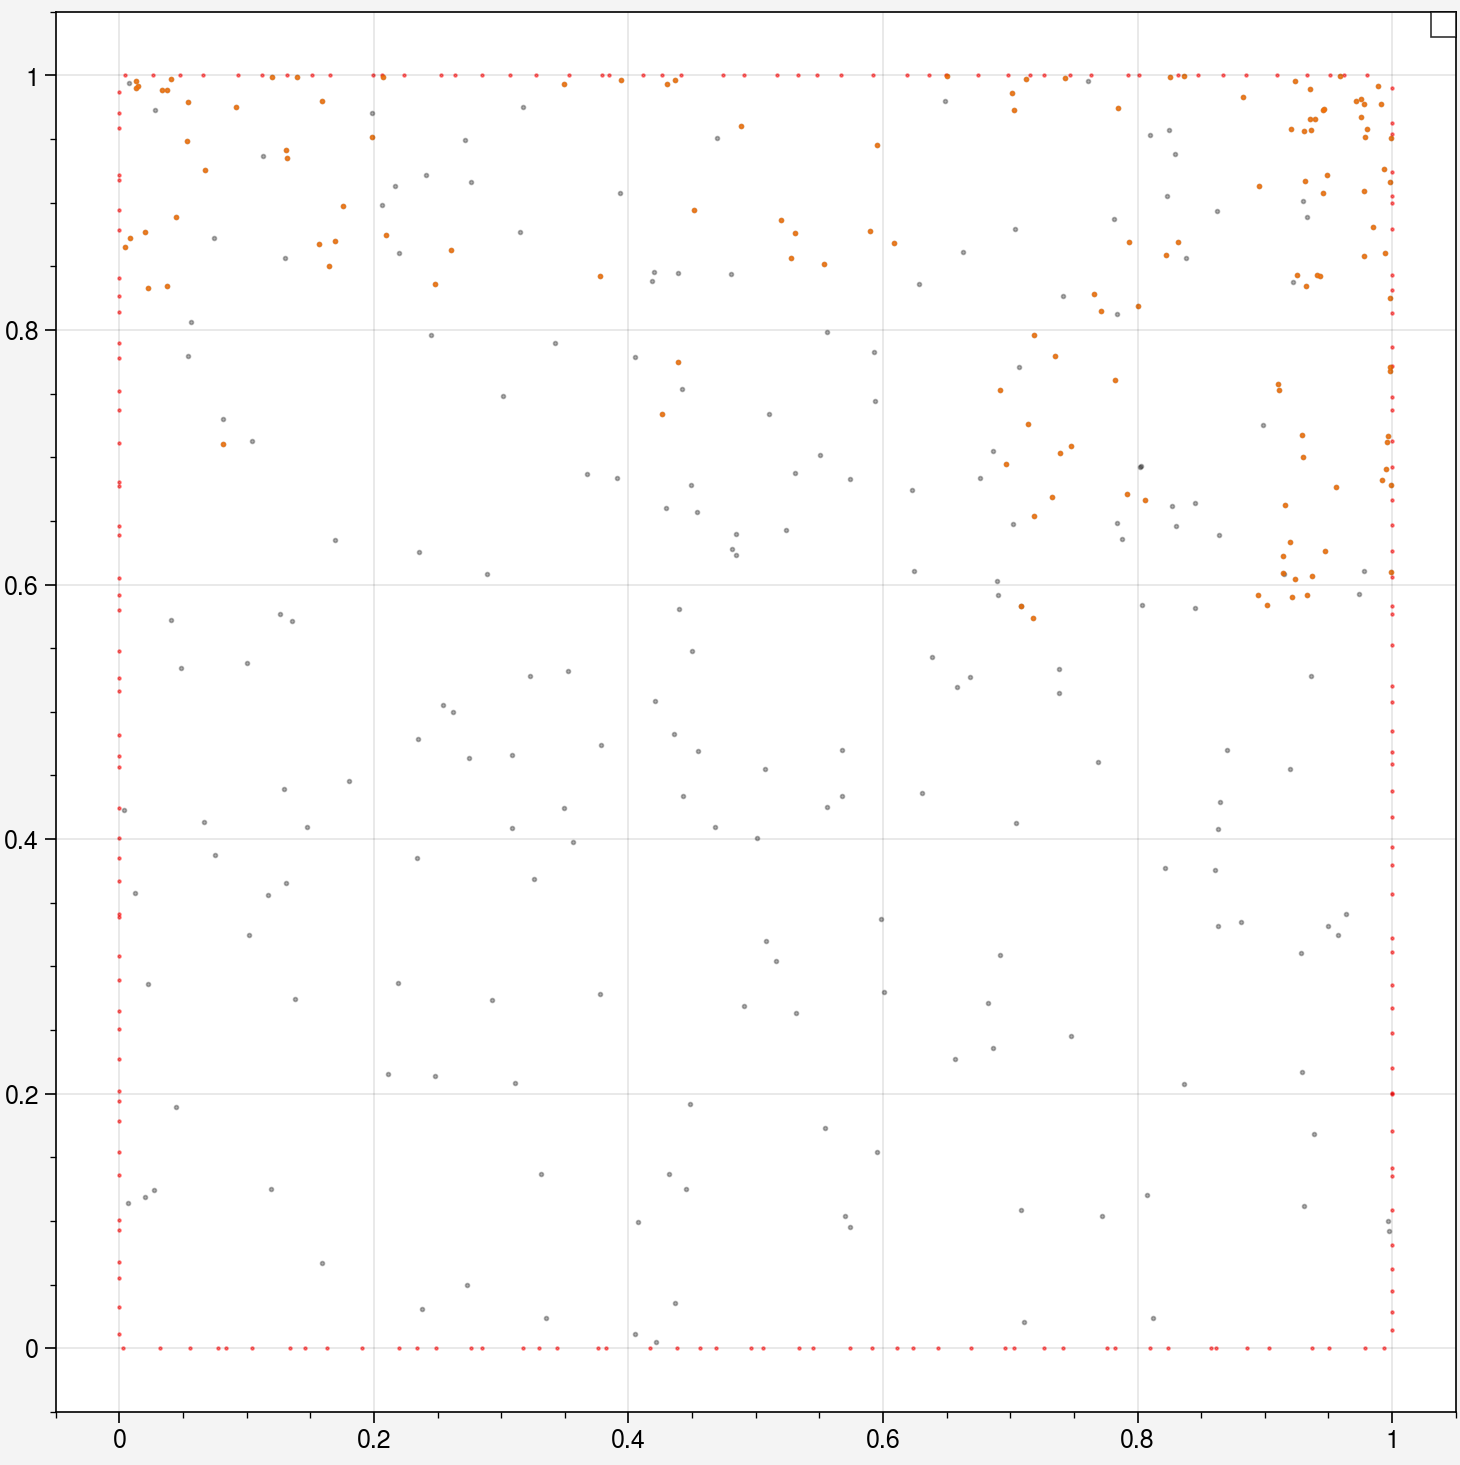

number of bound : ['0: 50', '1: 50', '2: 50', '3: 50']
number of area : ['0: 334']
Epoch: 2251, total_loss: 0.02682, bc_loss: 0.01740, pde_loss: 0.00943


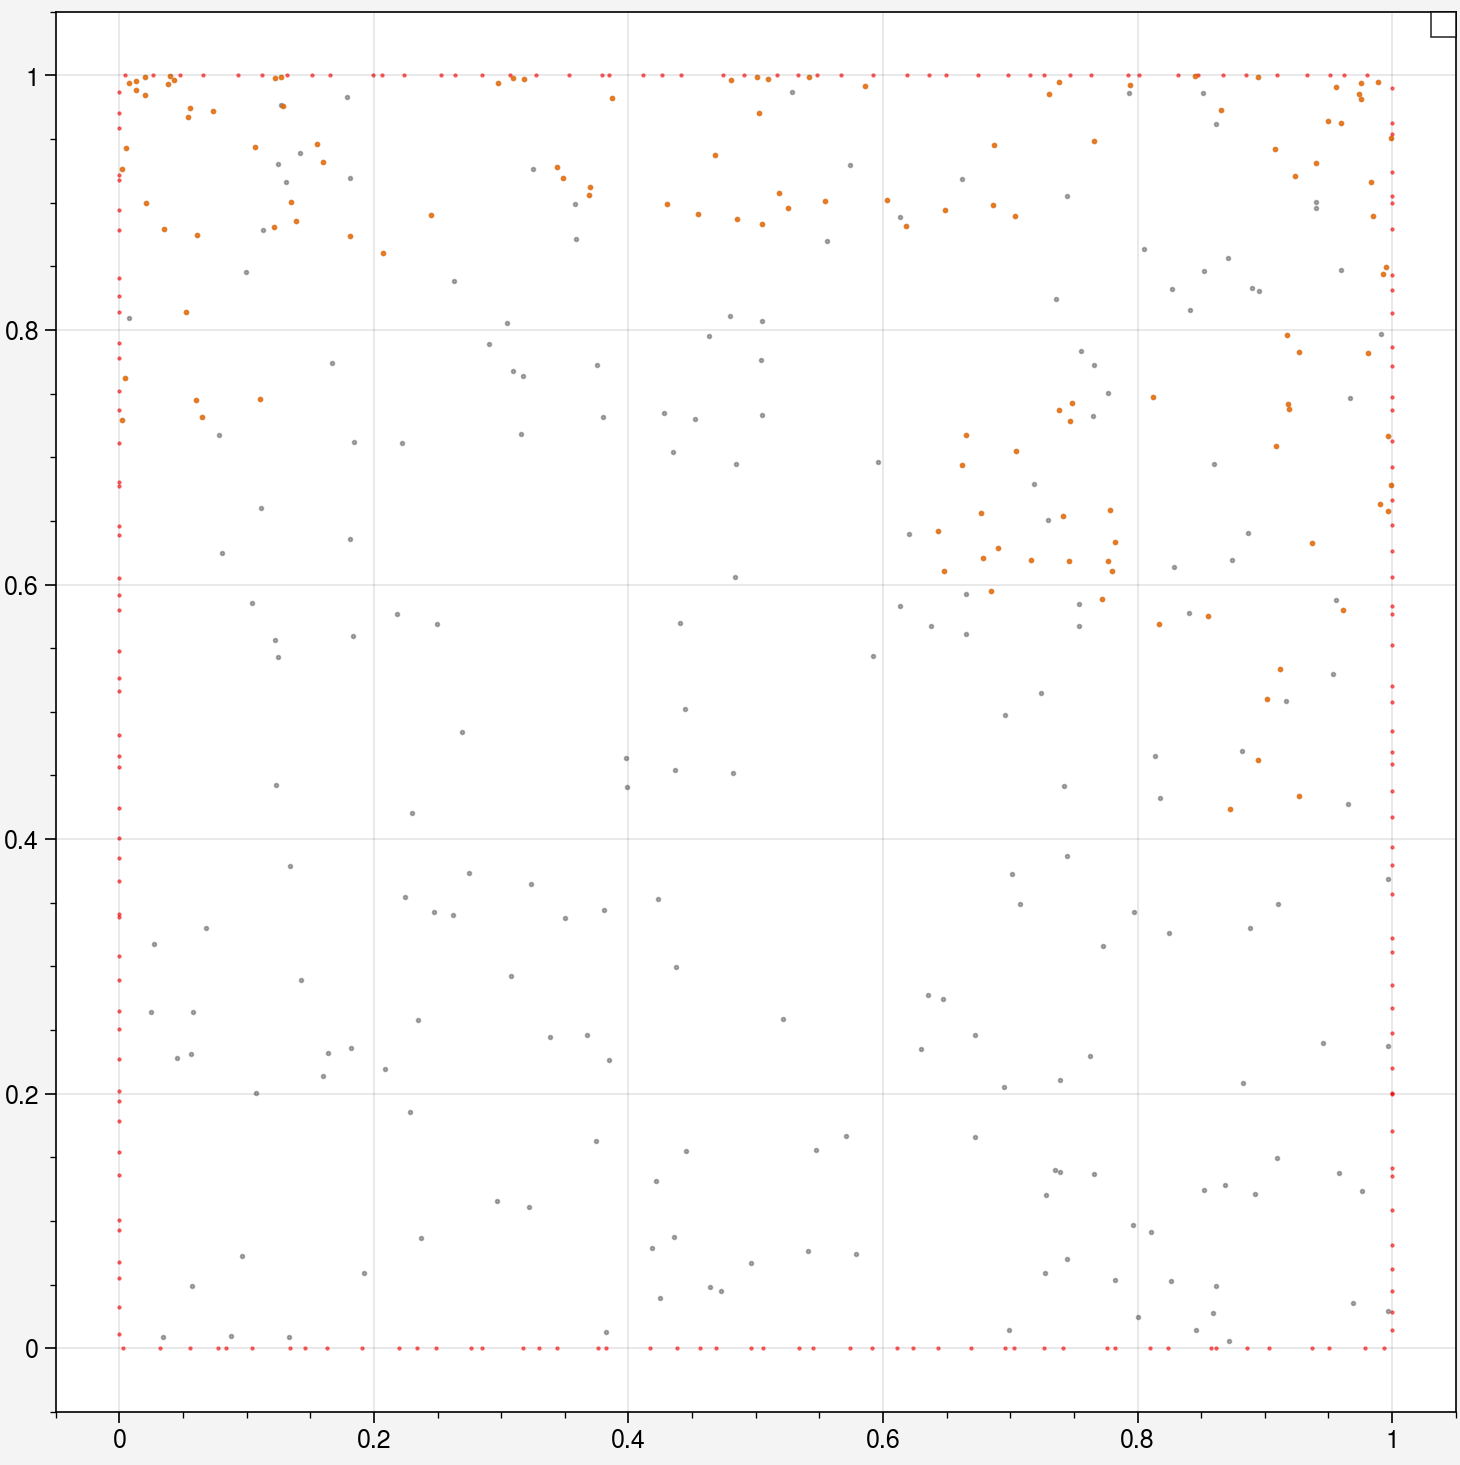

number of bound : ['0: 50', '1: 50', '2: 50', '3: 50']
number of area : ['0: 324']
Epoch: 2300, total_loss: 0.01517, bc_loss: 0.01192, pde_loss: 0.00326


In [ ]:
# Train the model
model3 = model2.train_lbfgs(
    calc_loss=df.calc_loss_weighted(domain, pde_weights=1),
    epochs=150,
    threshold_loss=0.0001,
    do_between_epochs=do_in_lbfgs)

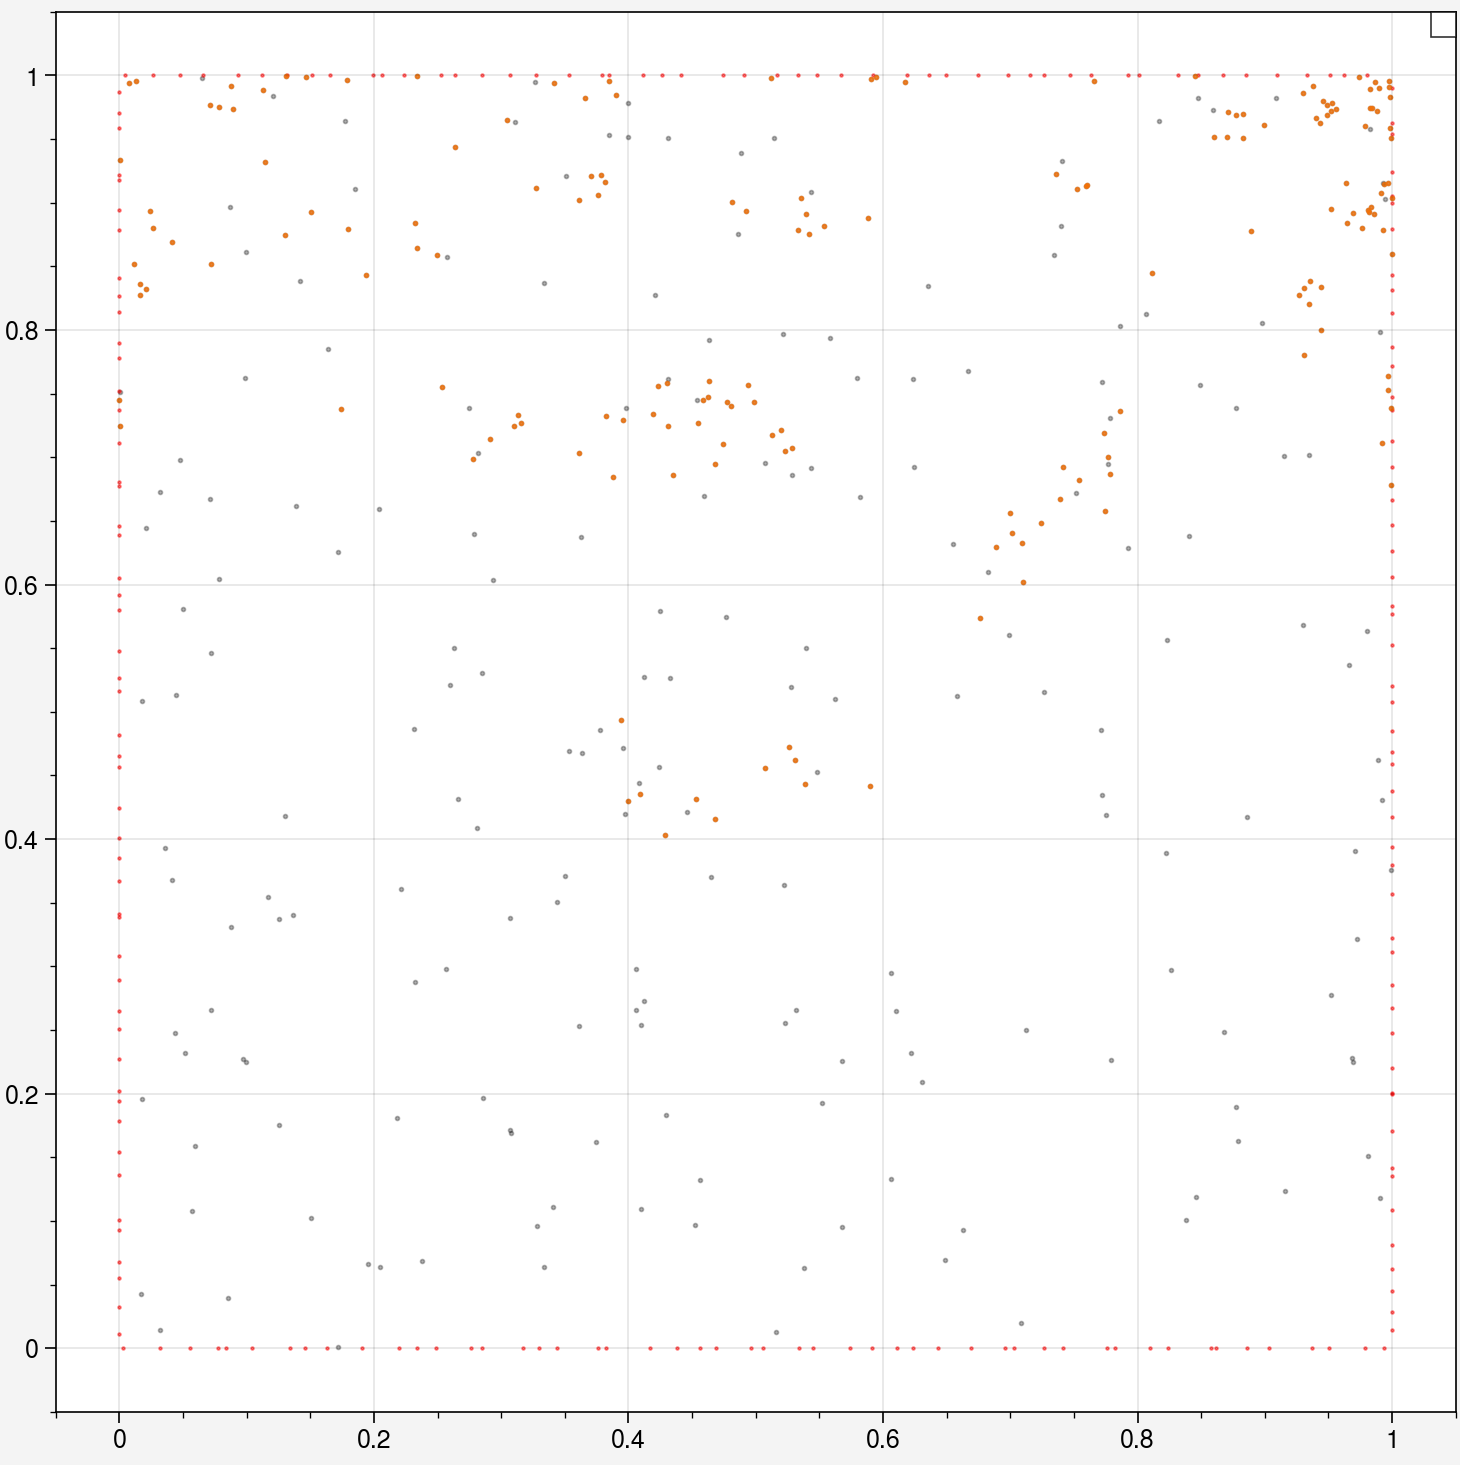

In [ ]:
domain.show_coordinates(display_physics=False, display_resampling=True)

Save or Load the model for later use

In [ ]:
model2.save_as_pickle("model.pkl")
model2 = df.load_from_pickle("model.pkl")

## 4. Visualization

### 4.1 Visualize area

In [ ]:
df.Visualizer.refwidth_default = 4

In [ ]:
# Create object for evaluation
area_eval = domain.area_list[0].evaluate(model3)
# Sampling uniform points
area_eval.sampling_area([200, 200])
# Show available data's key
print(area_eval)

Available data keys: ('u', 'v', 'p', 'pde_residual', 'x', 'y', 'u_x', 'u_y', 'v_x', 'v_y', 'p_x', 'p_y', 'continuity_residual', 'x_momentum_residual', 'y_momentum_residual', 'total_loss', 'bc_loss', 'pde_loss')


In [ ]:
area_eval['v_mag'] = (area_eval['u']**2 + area_eval['v']**2)**0.5

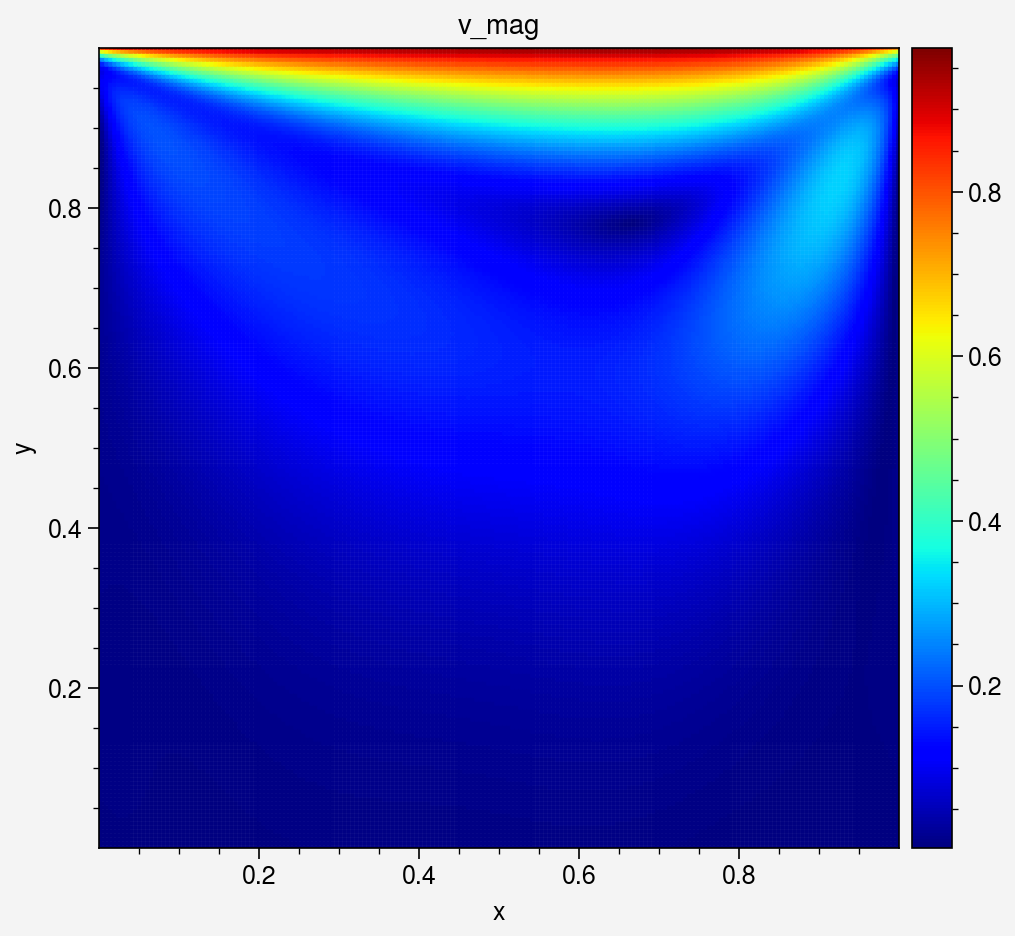

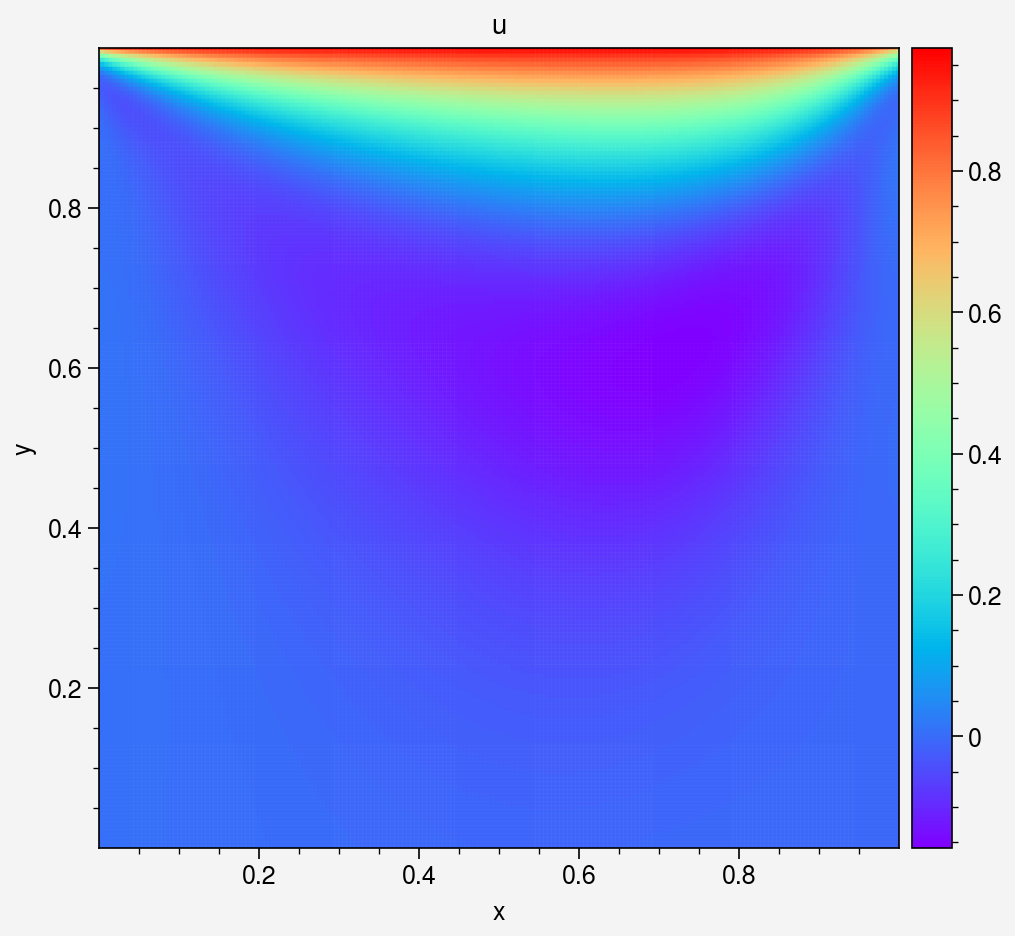

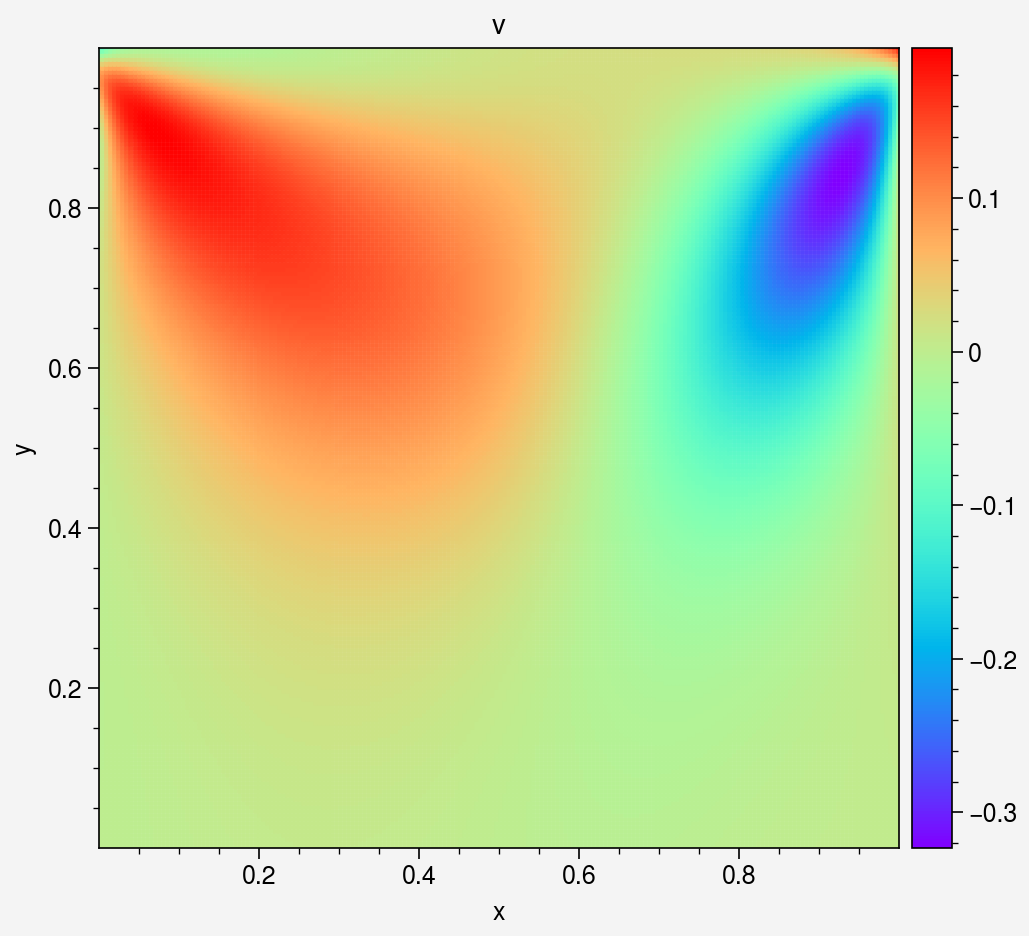

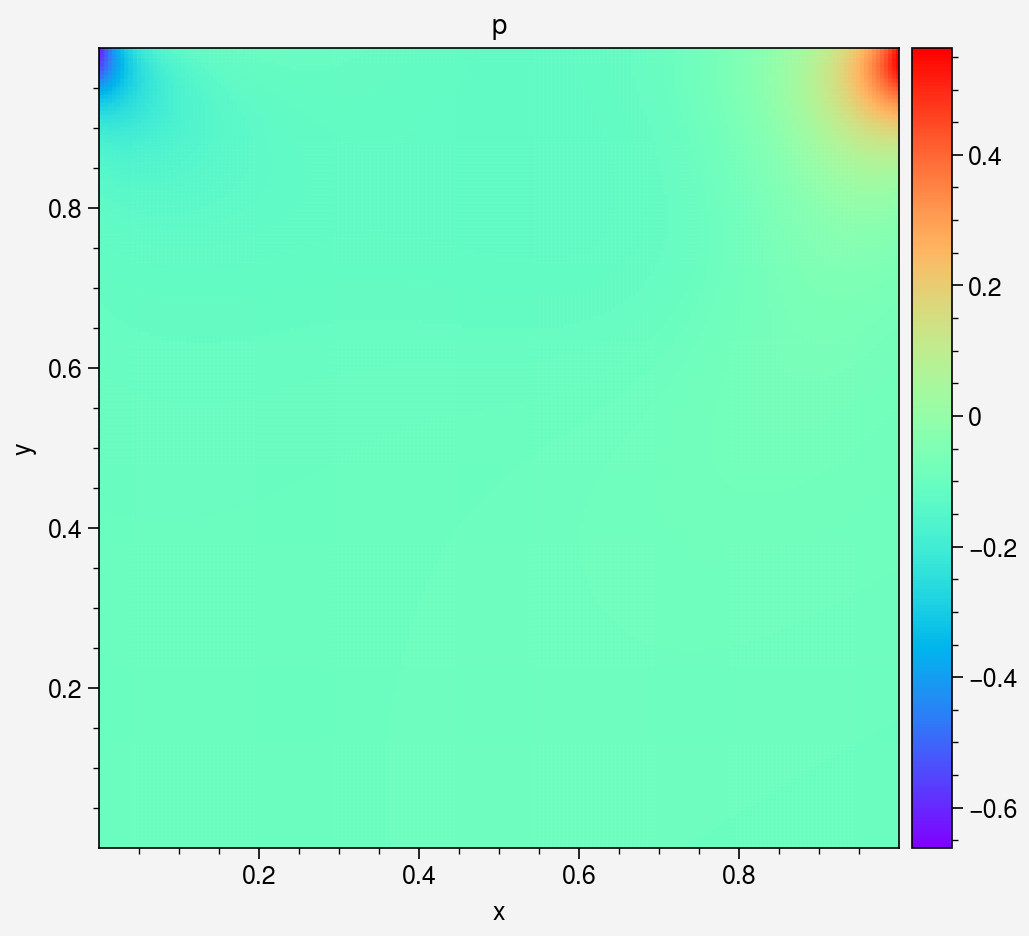

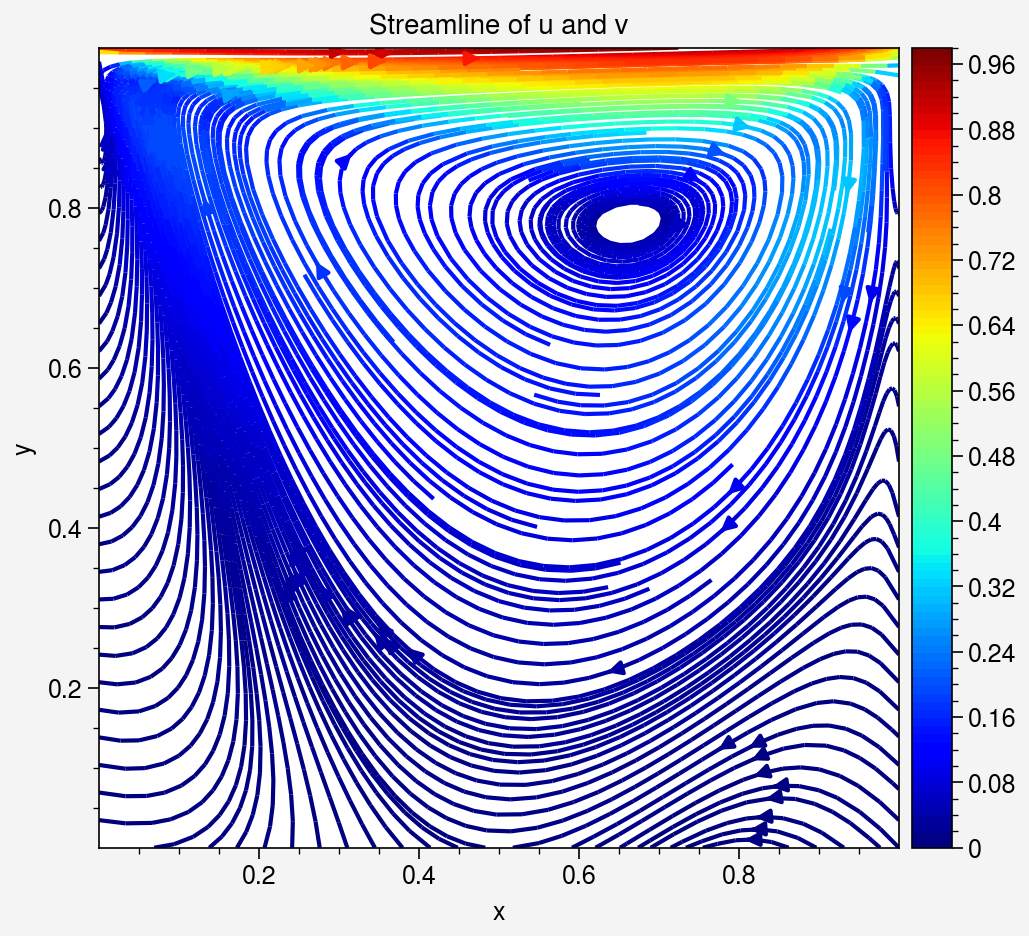

In [ ]:
_ = area_eval.plot_color('v_mag', s=1.5, cmap='jet').savefig("colorplot_v_mag.png")
_ = area_eval.plot_color('u', s=1.5, cmap='rainbow')
_ = area_eval.plot_color('v', s=1.5, cmap='rainbow')
_ = area_eval.plot_color('p', s=1.5, cmap='rainbow')
_ = area_eval.plot_streamline('u', 'v', cmap = 'jet')

## 4.2 Visualize Neural Network data

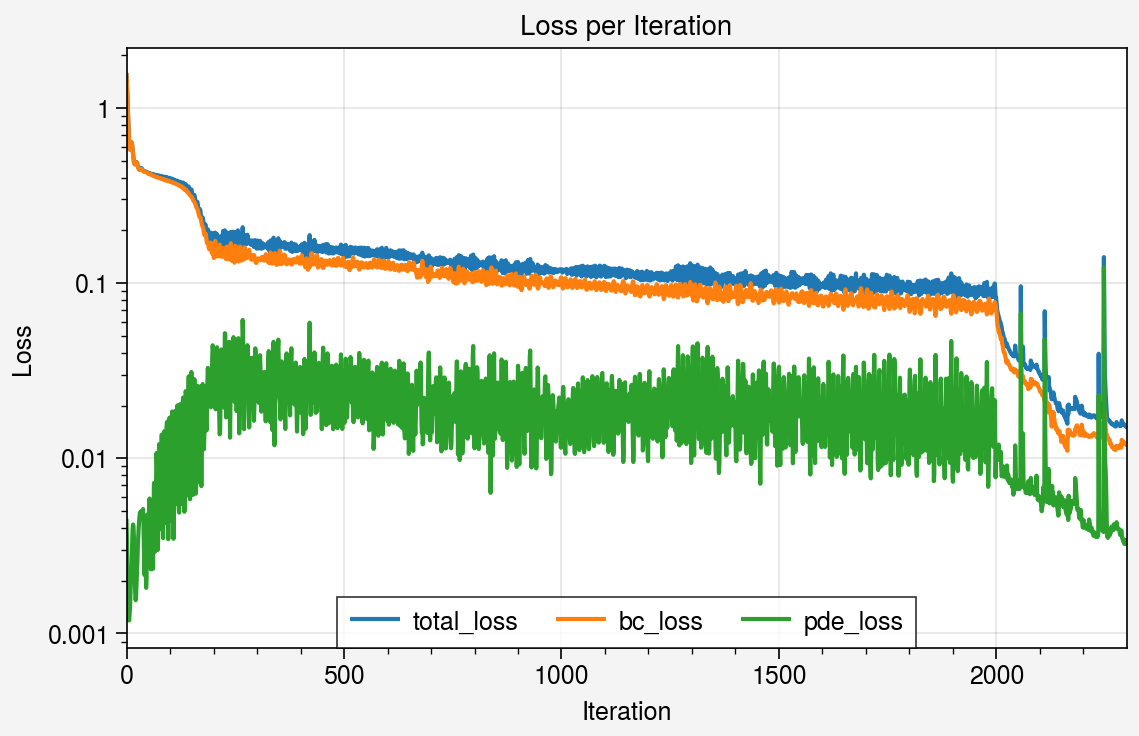

In [ ]:
_ = area_eval.plot_loss_curve(log_scale=True)

### 4.4 Export data

In [ ]:
# store the x,y,velocity_magnitude data
x_data = area_eval.data_dict['x']
y_data = area_eval.data_dict['y']
u_data = area_eval.data_dict['u']

#save as txt file
import numpy as np
array = np.column_stack((x_data, y_data, u_data))
np.savetxt('outlet_velocity.txt', array)